# Hands-on Machine Learning Practice

### Step - 1:

- Framing the Problem
    - Business Objective
    - How will the trained model be used
    - ML Algorithms: 
        - Supervised/Unsupervised/Reinforcement Learning? 
        - Classification/Regression/Dimensionality Reduction? 
        - Batch/Online learning?
    - Performance Measurement
        - MSE/RMSE/MAE?
        - Precision/Recall/F1 Score/AUC-ROC?
    - Assumptions

### Step-2:
- Getting the Data 

In [7]:
# Function to fetch the data

import os
import tarfile # read and write tar archive files
import urllib # working with URLs

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

print(HOUSING_PATH)
print(HOUSING_URL)

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True) # directory for the dataset
    tgz_path = os.path.join(housing_path, "housing.tgz") # defining the file path for the dataset
    urllib.request.urlretrieve(housing_url, tgz_path) # retrieving contents of a webpage
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

fetch_housing_data()

datasets/housing
https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.tgz


/var/folders/z7/2rz_5z4n6r323n45w2swvlqr0000gn/T/ipykernel_18370/711894008.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


In [8]:
# Loading the data into Pandas
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


#### Observations:

- Total Records: 20640, small dataset as per ML standards
- total_bedrooms have 20433 records, some districts missing this info -- Will be handled later
- ocean_proximity's datatype is object, so need to look into the data to understand better

In [10]:
# Identifying the values in ocean_proximity field

housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [11]:
# Summary of the numerical attributes

housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


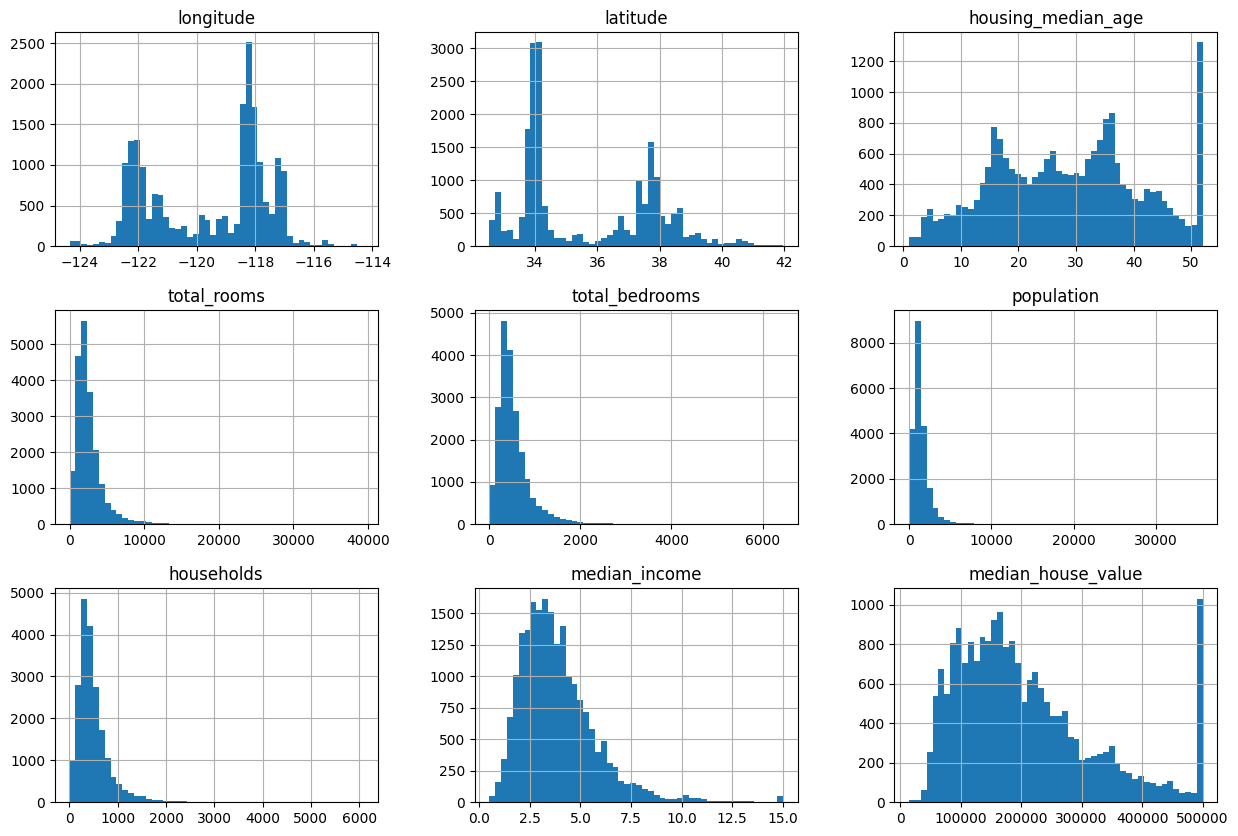

In [16]:
# Plotting histograms for the data

import matplotlib.pyplot as plt
%matplotlib inline
# plt.figure(figsize=(25,20))
housing.hist(bins=50, figsize=(15,10))
plt.show()

#### Observations:

- Features in the data have different scales. Need to be taken care of later.
- Most of the distributions are tail heavy. Need to transform these attributes later.

In [ ]:
# Create a Test Set

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

# Random Splitting
train_set, test_set = train_test_split(housing, test_size=0.20, random_state=42)

<Axes: >

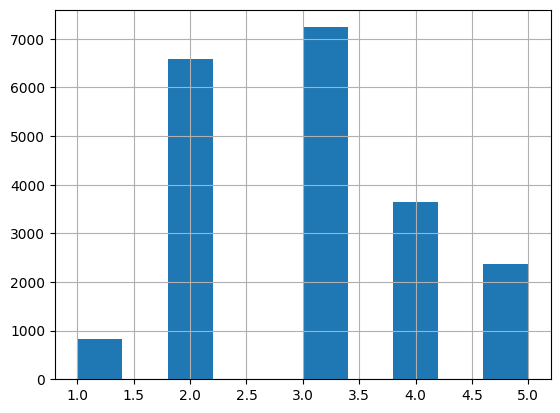

In [19]:
# Categorizing the median_income field

import numpy as np

housing['income_cat'] = pd.cut(housing['median_income'], bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf],
                            labels=[1,2,3,4,5])

housing['income_cat'].hist()

In [ ]:
# Stratified Splitting - To ensure homogenity in the Sample data wrt income_category

strat = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
for train_index, test_index in strat.split(housing, housing['income_cat']):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [21]:
# Check homogenity

strat_train_set['income_cat'].value_counts()/len(strat_train_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [22]:
# Removing the income_category feature

for set_ in (strat_train_set, strat_test_set):
    set_.drop('income_cat', axis=1, inplace=True)